In [2]:
import os
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.colors import TwoSlopeNorm, Normalize, BoundaryNorm, ListedColormap
from matplotlib import gridspec
from matplotlib.patches import Patch
import matplotlib.cm as cm
import mapclassify as mc
from matplotlib.colors import ListedColormap

import warnings
warnings.filterwarnings("ignore")

## Plot HAB distribution maps

In [6]:
hab = gpd.read_file('data/HAB/HAB_Events_2019-2023_3mile.shp') # This raw dataset is not uploaded to GitHub
fl = gpd.read_file('data/Shapefile/cb_2019_12_county.shp')

print(f'There are {len(hab)} HAB events')
for year in range(2019, 2024):
    print(f'  Year {year}: {len(hab[hab['YEAR']==year])}')

There are 43089 HAB events
  Year 2019: 8542
  Year 2020: 6418
  Year 2021: 10370
  Year 2022: 8236
  Year 2023: 9523


**Assign categories based on count**

In [8]:
conditions = [
    hab['COUNT_'] > 1e6,
    hab['COUNT_'] > 1e5,
    hab['COUNT_'] > 1e4,
    hab['COUNT_'] > 1e3
]
categories = ['High', 'Medium', 'Low', 'Very Low']
hab['CATEGORY'] = np.select(conditions, categories, default='Background')

**Plot HAB events by year**

In [9]:
category_colors = {
    'Background': '#ffffb2',
    'Very Low': '#fecc5c',
    'Low': '#fd8d3c',
    'Medium': '#f03b20',
    'High': '#bd0026'
}
order = list(category_colors.keys())
colors = list(category_colors.values())
category = [
    'Background (0-1,000 cells/liter)',
    'Very Low (1,000-10,000 cells/liter)',
    'Low (10,000-100,000 cells/liter)',
    'Medium (100,000-1,000,000 cells/liter)',
    'High (>1,000,000 cells/liter)']

new_cmap = ListedColormap(colors)

In [10]:
def plot_HAB_each_year(ax, year):
    fl.plot(facecolor='gainsboro', edgecolor='black', linewidth=0.2, ax=ax)
    temp = hab[hab['YEAR'] == year].copy()
    for i in range(5): # Plot the categories one by one, cause I want the High to be at top
        temp[temp['CATEGORY'] == order[i]].plot(markersize=8, alpha=0.5, edgecolor='black', linewidth=0.1, color=colors[i], ax=ax)
    
    ax.axis('off')
    ax.set_title(year, fontsize=20)

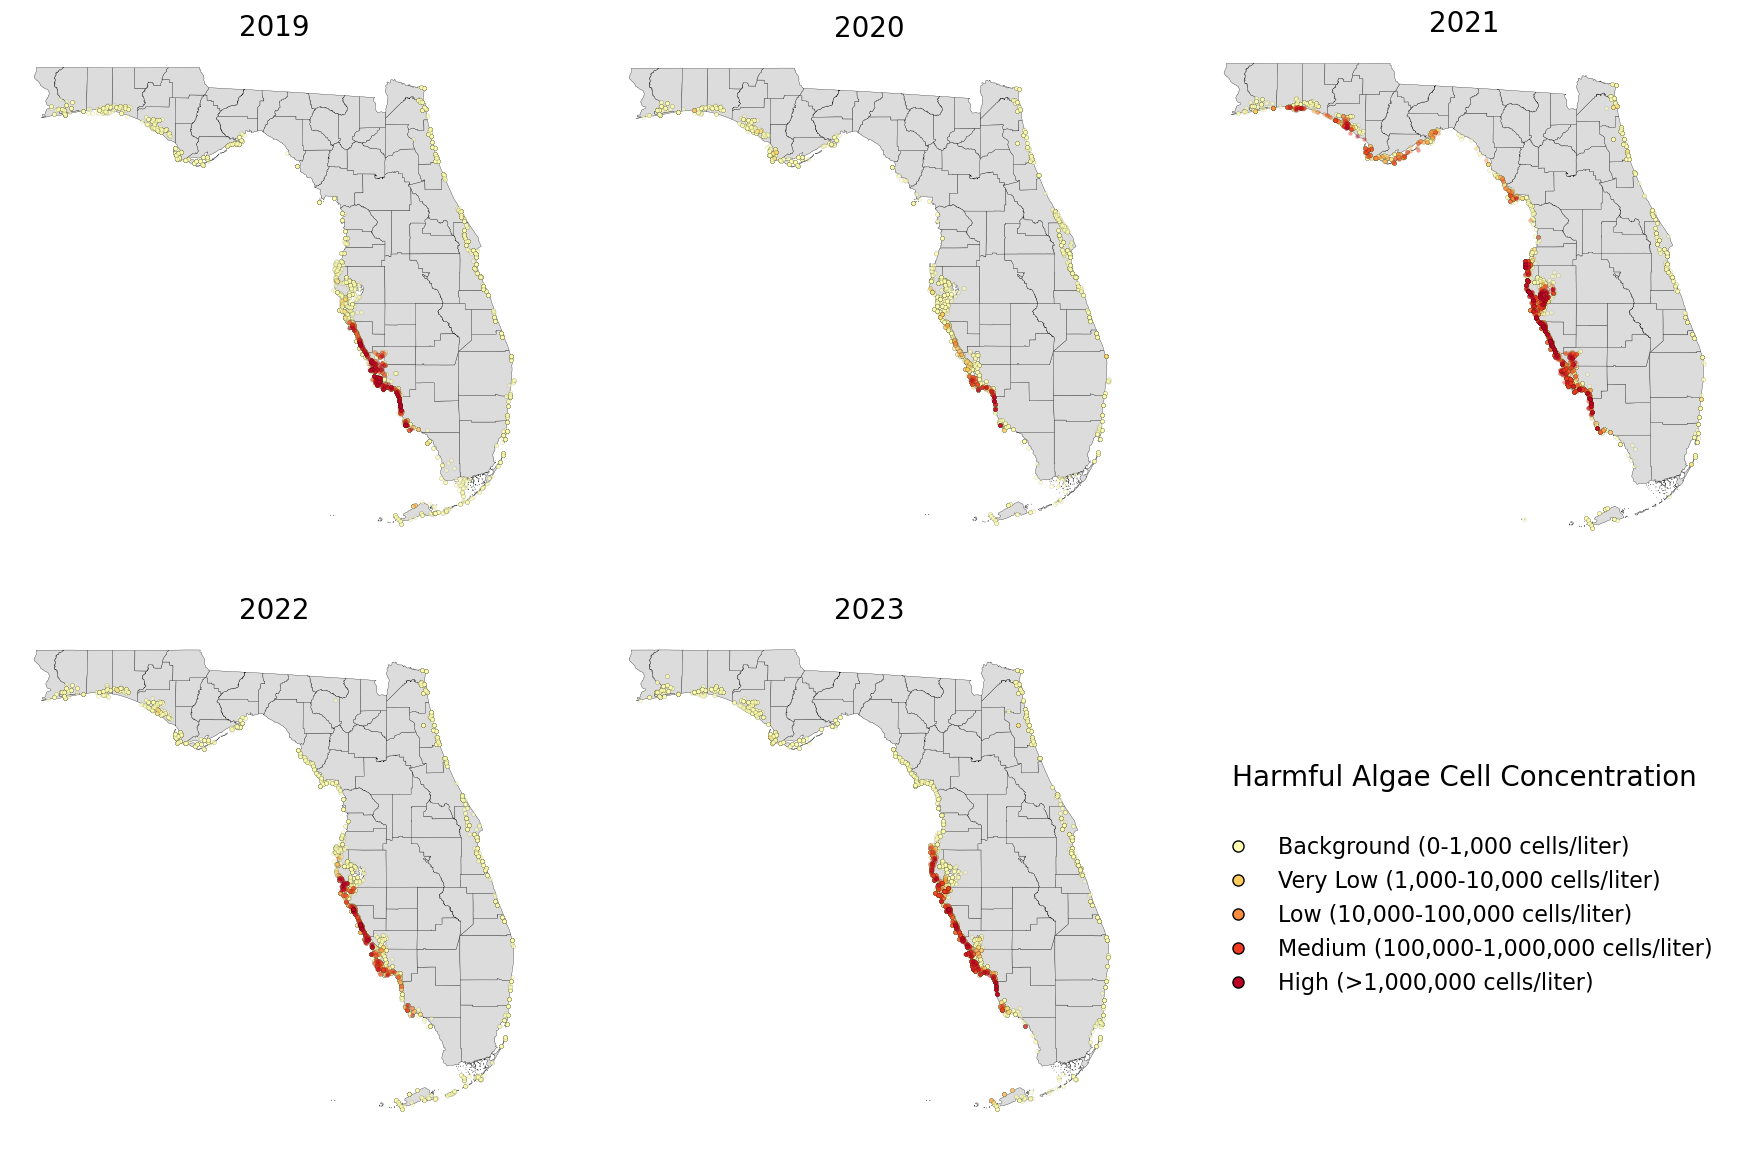

In [11]:
plt.figure(figsize=(18, 12))

years = range(2019, 2024)
for i in range(5):
    # print(years[i])
    ax = plt.subplot(2, 3, i+1)
    plot_HAB_each_year(ax, years[i])

# Create custom legend with edgecolor
ax = plt.subplot(2, 3, 6)
ax.axis('off')
handles = [Line2D([0], [0], marker='o', color='none', markerfacecolor=colors[i], markeredgecolor='black', markersize=8, label=category[i])
           for i in range(5)]
ax.legend(handles=handles, title='Harmful Algae Cell Concentration\n', loc='center', frameon=False, title_fontsize=20, fontsize=16)

plt.tight_layout()
plt.show()

## Plot the trends by week

In [5]:
# Read in the analysis-ready dataset
df = pd.read_stata('data/algae_reg_3mile.dta')
df = df.astype({'GEOID': 'int64', 'year': 'int', 'month': 'int', 'week1': 'int'}).astype({'GEOID': 'str'})

In [8]:
# Read in shapefiles
tracts = gpd.read_file('data/Shapefile/tl_2019_12_tract_coastal.shp')
county = gpd.read_file('data/Shapefile/cb_2019_12_county.shp')
print(f'There are {len(df['GEOID'].unique())} GEOID in tracts' )

There are 3260 GEOID in tracts


In [7]:
def plot_trend_by_weeks(ax, y, y_label):
    print(y)
    
    years = range(2019, 2024)
    colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
    
    # I know I can use the hue= parameter, but I just want to know the plotting process
    for i in range(5):
        temp = df[df['year'] == years[i]]
        week_day = temp[['week']].drop_duplicates()
        week_day['day'] = week_day['week'].dt.dayofyear
        temp = temp.merge(week_day, on='week')
        
        sns.lineplot(data=temp, x='day', y=y, label=years[i], color=colors[i], ax=ax)
    
    # Set the x labels
    ax.set_xlabel('Month')
    ax.set_xticks(
        [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335],
        ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12']
    )
    # Set the y labels
    # ylim = df.groupby(['week1', 'year']).agg({y: 'mean'})
    # y_min, y_max = ylim.min().values[0], ylim.max().values[0]
    y_min, y_max = ax.get_ylim()
    y_scale = y_max - y_min
    y_min -= y_scale*0.1
    y_max += y_scale*0.1
    ax.set_ylim(y_min, y_max)
    ax.set_ylabel(y_label)
    # ax.set_yticks([30, 35, 40, 45, 50], ['30', '35', '40', '45', '50'])
    
    # Shade the 4 seasons
    groups = [
        (1, 60, 'lightgray'),
        (60, 152, 'lightpink'),
        (152, 244, 'lightgoldenrodyellow'),
        (244, 335, 'wheat'),
        (335, 365, 'lightgray')
    ]
    for start, end, color in groups:
        ax.axvspan(start, end, color=color, alpha=0.3)
    text_loc_y = y_max - y_scale*0.05
    ax.text(30, text_loc_y, 'Winter', ha='center', va='center')
    ax.text(106, text_loc_y, 'Spring', ha='center', va='center')
    ax.text(198, text_loc_y, 'Summer', ha='center', va='center')
    ax.text(290, text_loc_y, 'Fall', ha='center', va='center')
    # ax.text(350, text_loc_y, 'Winter', ha='center', va='center')
    
    plt.legend(title='', loc='lower center', ncol=5)

Total_time
visit_od_all
average_cell_m
total_cell_m


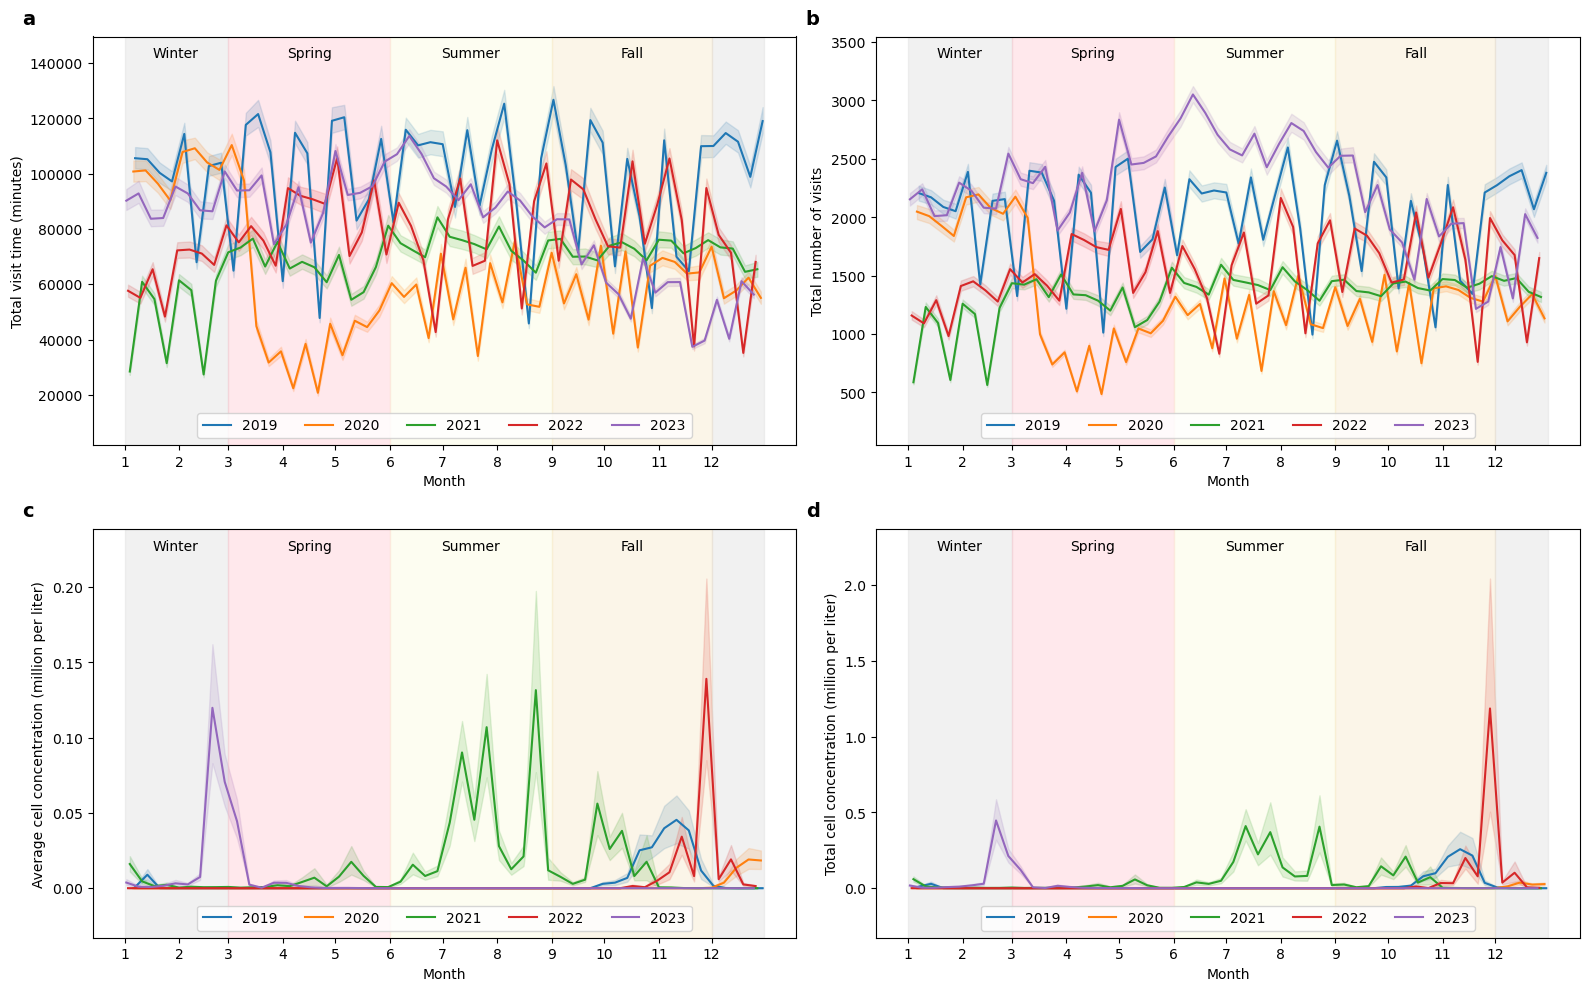

In [8]:
plt.figure(figsize=(16, 10))

ax = plt.subplot(2, 2, 1)
y, y_label = 'Total_time', 'Total visit time (minutes)'
plot_trend_by_weeks(ax, y, y_label)
ax.text(-0.1, 1.03, 'a', fontsize=14, weight='bold', transform=ax.transAxes)

ax = plt.subplot(2, 2, 2)
y, y_label = 'visit_od_all', 'Total number of visits'
plot_trend_by_weeks(ax, y, y_label)
ax.text(-0.1, 1.03, 'b', fontsize=14, weight='bold', transform=ax.transAxes)

ax = plt.subplot(2, 2, 3)
y, y_label = 'average_cell_m', 'Average cell concentration (million per liter)'
plot_trend_by_weeks(ax, y, y_label)
ax.text(-0.1, 1.03, 'c', fontsize=14, weight='bold', transform=ax.transAxes)

ax = plt.subplot(2, 2, 4)
y, y_label = 'total_cell_m', 'Total cell concentration (million per liter)'
plot_trend_by_weeks(ax, y, y_label)
ax.text(-0.1, 1.03, 'd', fontsize=14, weight='bold', transform=ax.transAxes)


plt.tight_layout()
plt.show()

## Plot the maps of the trends

In [16]:
def plot_trends_map(y, y_label, colors='OrRd', breaks='NaturalBreaks'):
    df2 = df.groupby(['GEOID', 'year']).agg({y: 'mean'}).reset_index()
    cmap = cm.get_cmap(colors, 5)
    if breaks == 'NaturalBreaks':
        norm = BoundaryNorm([df2[y].min()]+mc.NaturalBreaks(df2[y], k=5).bins.tolist(), 5) # Use user-defined classification
    elif breaks == 'Quantiles':
        norm = BoundaryNorm([df2[y].min()]+mc.Quantiles(df2[y], k=5).bins.tolist(), 5)
    else:
        print('The breaks parameter must be either \'NaturalBreaks\' or \'Quantiles\'')
        return None
    
    fig = plt.figure(figsize=(18, 12))

    # Plot each year
    years = range(2019, 2024)
    for i in range(5):
        print(years[i])
        ax = plt.subplot(2, 3, i+1)
        
        # Prepare the data
        temp = df2[df2['year'] == years[i]]
        temp = tracts.merge(temp, on='GEOID')
        # Plot
        temp.plot(column=y, norm=norm, cmap=cmap, ax=ax)
        county.plot(facecolor='none', edgecolor='black', linewidth=0.4, ax=ax)
        
        ax.axis('off')
        ax.set_title(years[i], fontsize=20)
    
    # Add a shared colorbar
    cax = fig.add_axes([0.86, 0.1, 0.02, 0.25]) # [left, bottom, width, height]
    cb = plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), cax=cax)
    # Disable the scientific notation
    cb.formatter.set_useOffset(False)
    cb.formatter.set_scientific(False)
    cb.update_ticks()
    # cb.set_label(y_label, fontsize=14)
    cax.set_title(y_label+'\n', pad=10, fontsize=18)
    cb.ax.tick_params(labelsize=14)
    
    plt.tight_layout()
    # plt.savefig(f'figures/TrendsMap_{y}.png', dpi=400)
    plt.show()

2019
2020
2021
2022
2023


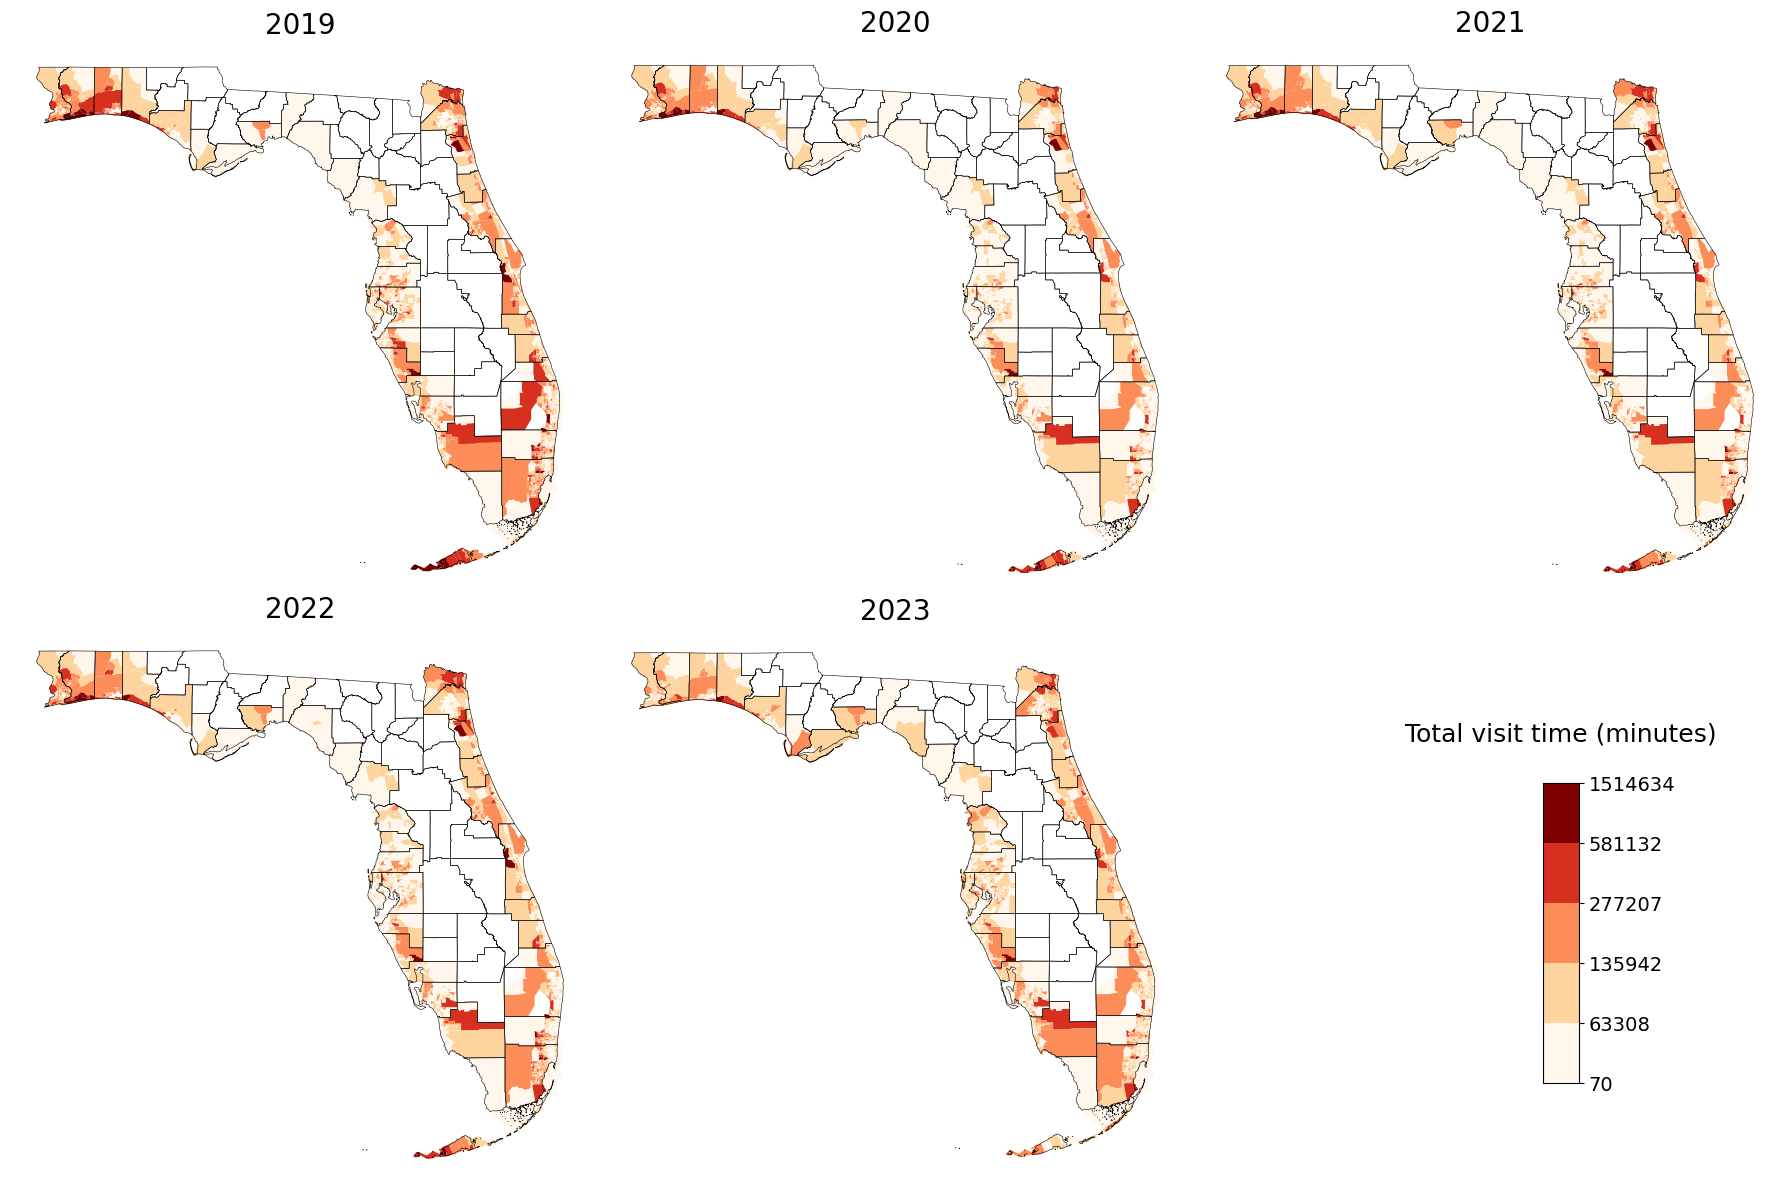

In [17]:
y, y_label, colors = 'Total_time', 'Total visit time (minutes)', 'OrRd'
plot_trends_map(y, y_label, colors)

2019
2020
2021
2022
2023


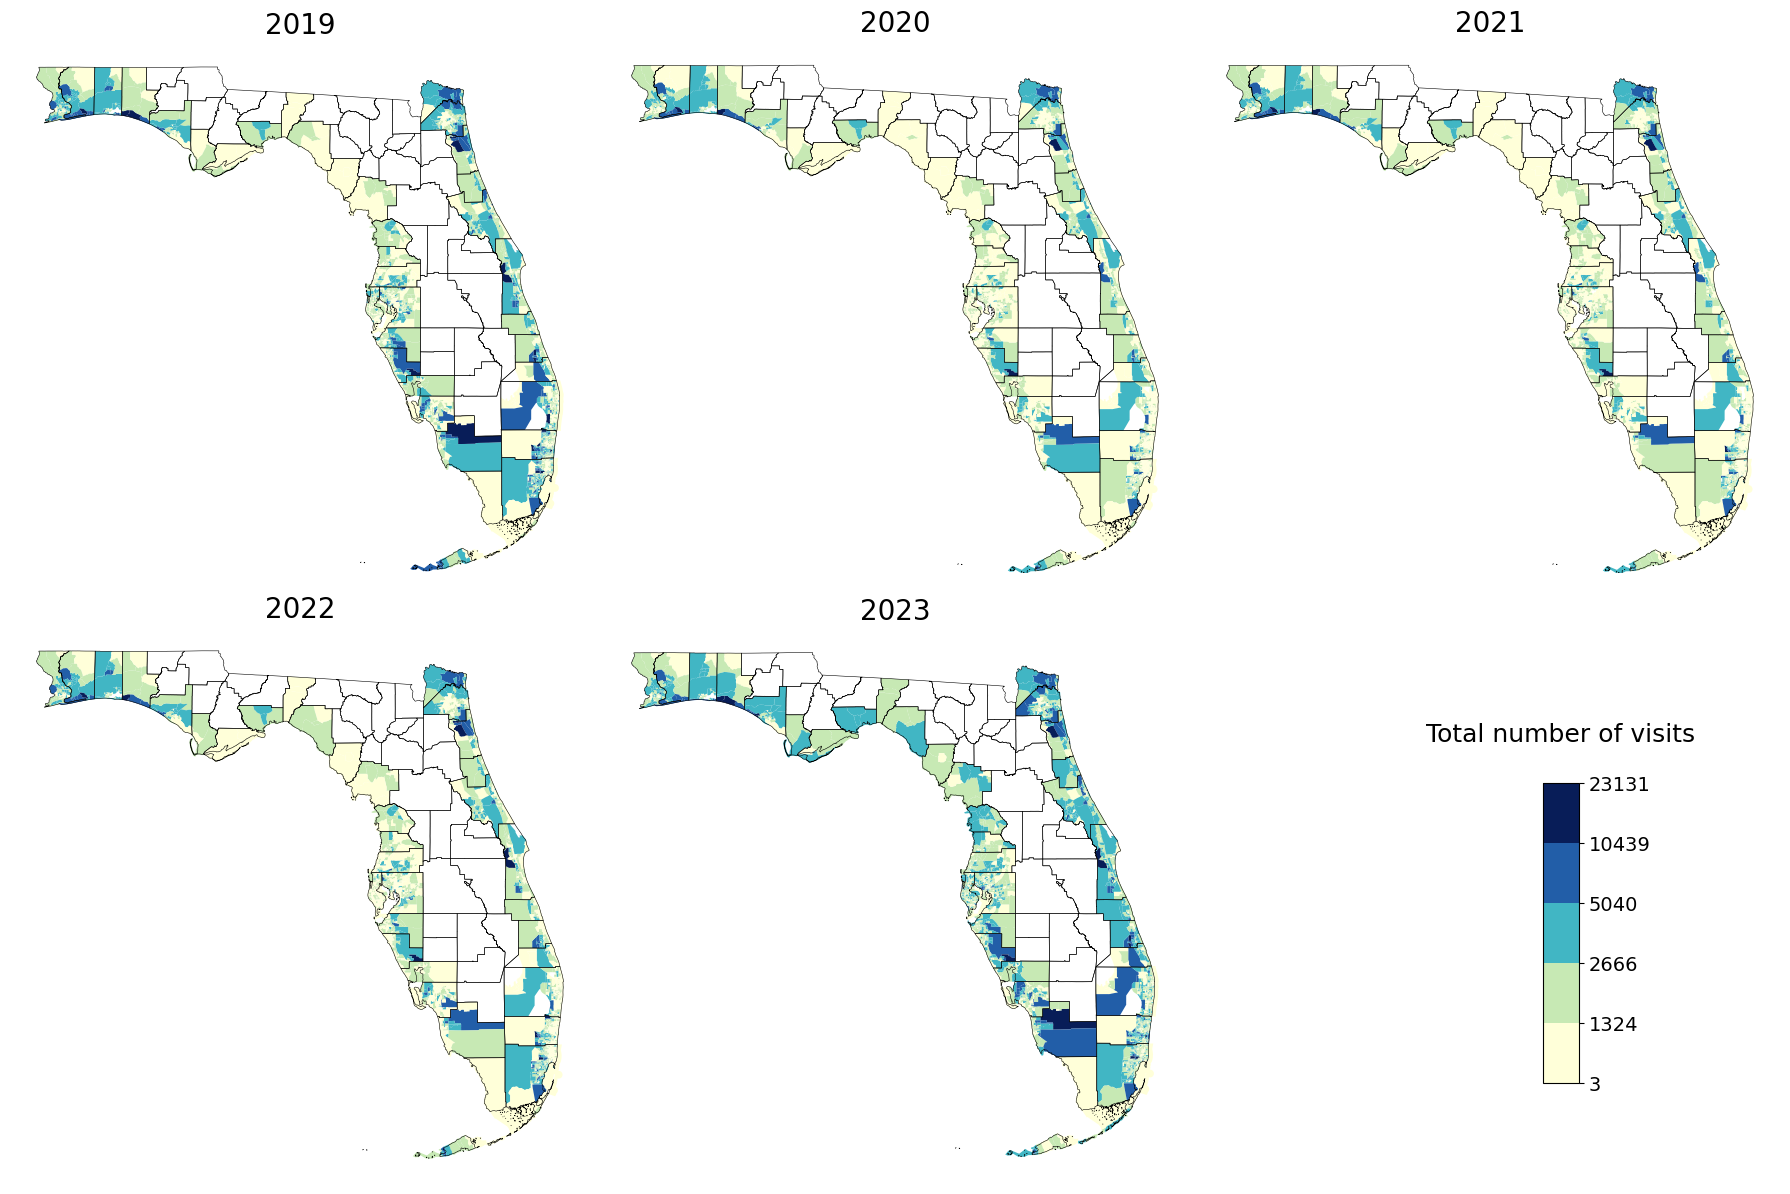

In [18]:
y, y_label, colors = 'visit_od_all', 'Total number of visits', 'YlGnBu'
plot_trends_map(y, y_label, colors)

2019
2020
2021
2022
2023


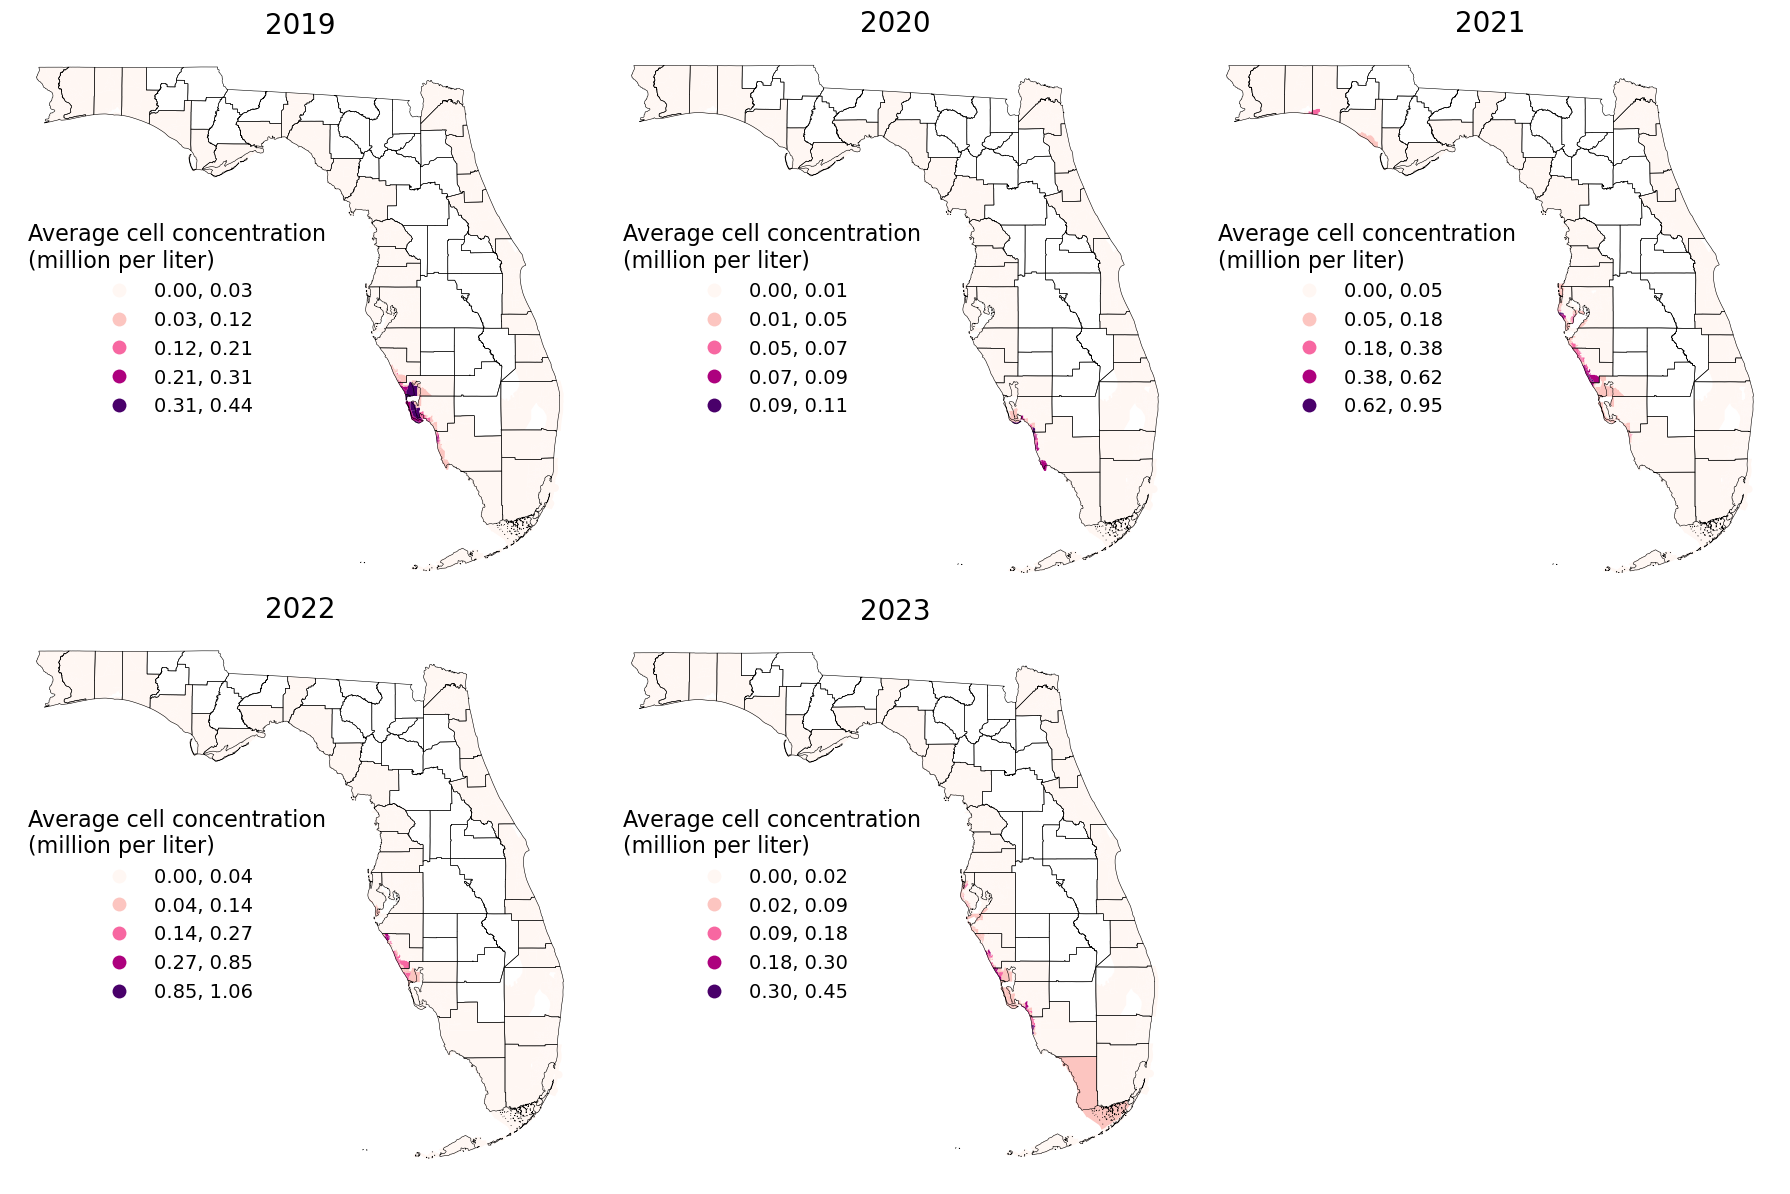

In [37]:
y, y_label, colors = 'average_cell_m', 'Average cell concentration\n(million per liter)', 'RdPu'

df2 = df.groupby(['GEOID', 'year']).agg({y: 'mean'}).reset_index()  
fig = plt.figure(figsize=(18, 12))

# Plot each year
years = range(2019, 2024)
for i in range(5):
    print(years[i])
    ax = plt.subplot(2, 3, i+1)
    
    # Prepare the data
    temp = df2[df2['year'] == years[i]]
    temp = tracts.merge(temp, on='GEOID')
    # Plot
    temp.plot(column=y, cmap=colors, scheme='NaturalBreaks', k=5, legend=True, ax=ax,
              legend_kwds={'title': y_label, 'loc': 'center left', 'frameon': False, 'title_fontsize': 16, 'fontsize': 14})
    county.plot(facecolor='none', edgecolor='black', linewidth=0.4, ax=ax)
    
    ax.axis('off')
    ax.set_title(years[i], fontsize=20)
    

plt.tight_layout()
plt.savefig(f'Figs/HAB_paper_figures/TrendsMap_{y}_SeparateLegend.png', dpi=400)
plt.show()

2019
2020
2021
2022
2023


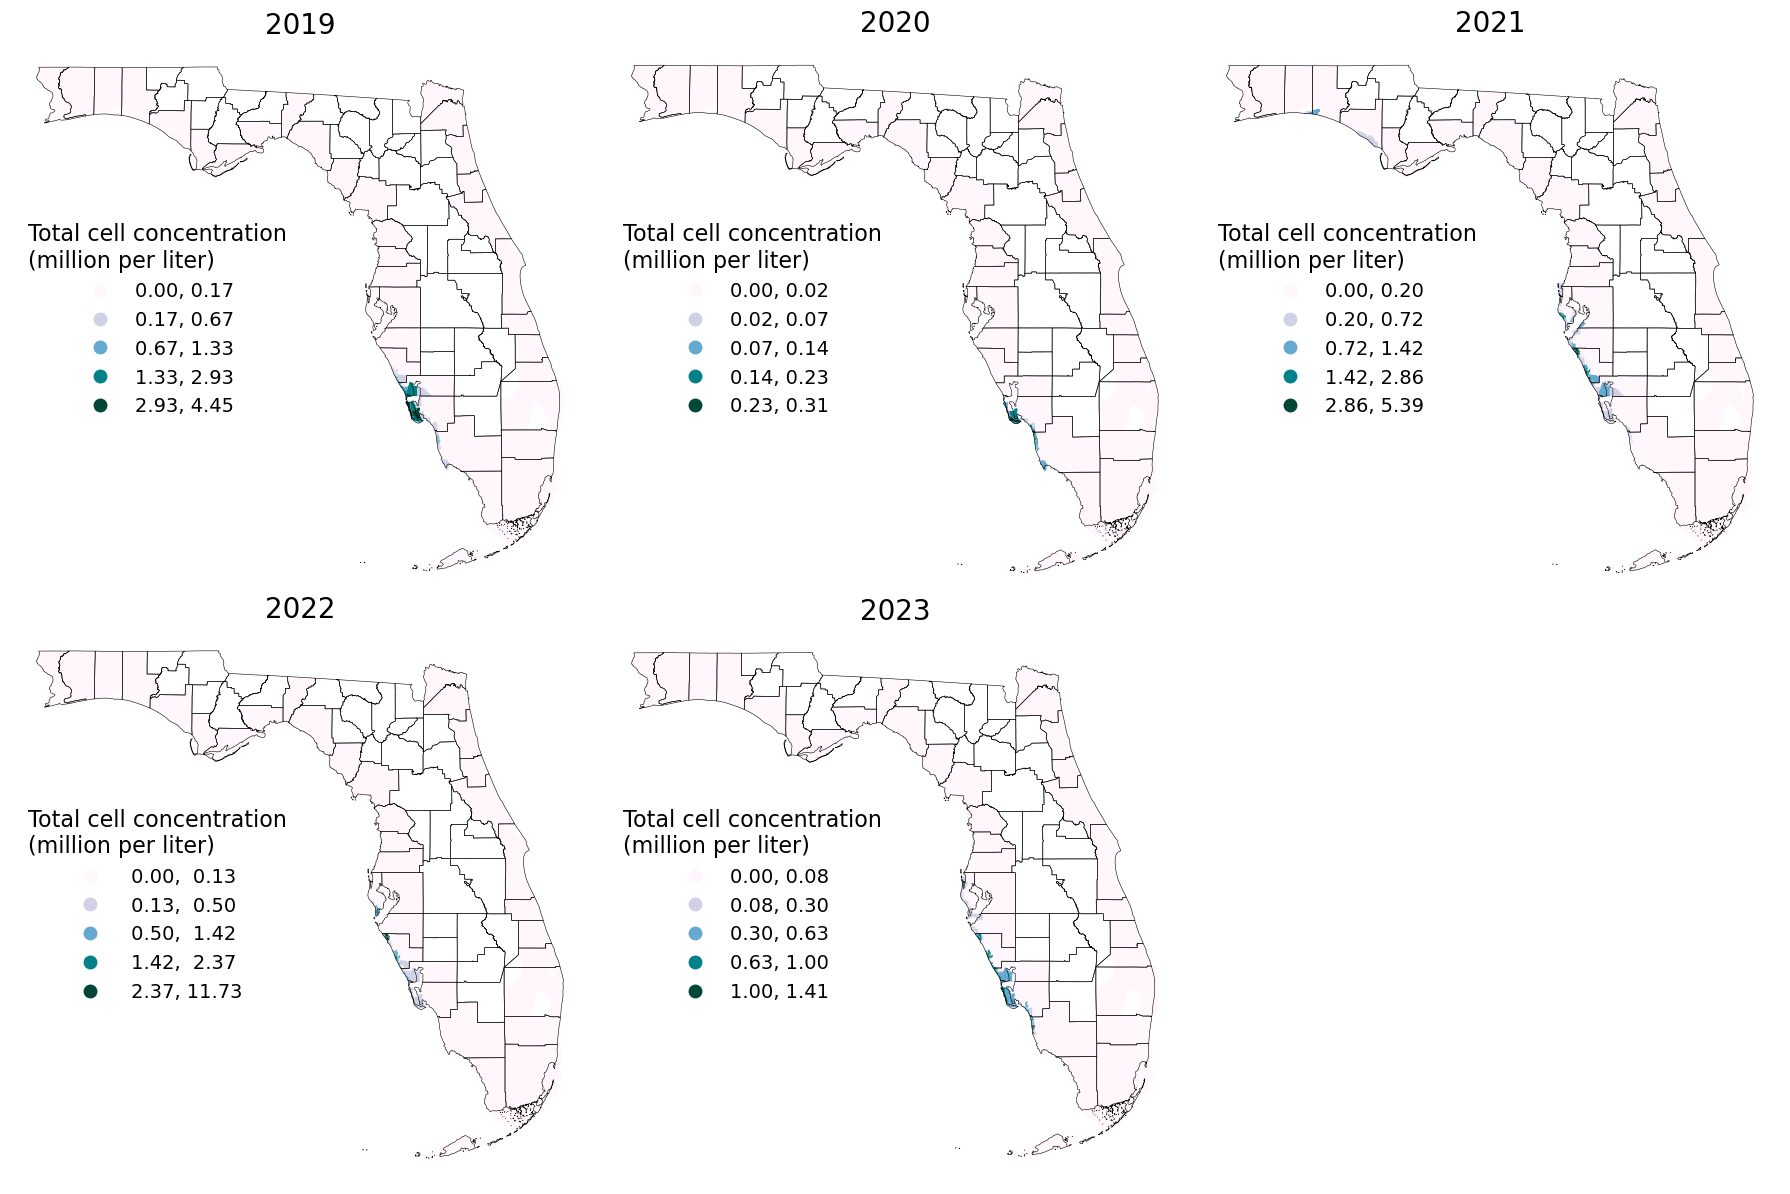

In [39]:
y, y_label, colors = 'total_cell_m', 'Total cell concentration\n(million per liter)', 'PuBuGn'

df2 = df.groupby(['GEOID', 'year']).agg({y: 'mean'}).reset_index()  
fig = plt.figure(figsize=(18, 12))

# Plot each year
years = range(2019, 2024)
for i in range(5):
    print(years[i])
    ax = plt.subplot(2, 3, i+1)
    
    # Prepare the data
    temp = df2[df2['year'] == years[i]]
    temp = tracts.merge(temp, on='GEOID')
    # Plot
    temp.plot(column=y, cmap=colors, scheme='NaturalBreaks', k=5, legend=True, ax=ax,
              legend_kwds={'title': y_label, 'loc': 'center left', 'frameon': False, 'title_fontsize': 16, 'fontsize': 14})
    county.plot(facecolor='none', edgecolor='black', linewidth=0.4, ax=ax)
    
    ax.axis('off')
    ax.set_title(years[i], fontsize=20)

plt.tight_layout()
plt.savefig(f'Figs/HAB_paper_figures/TrendsMap_{y}_SeparateLegend.png', dpi=400)
plt.show()

## Plot the Economic Loss

In [9]:
df3 = df[df['year'] == 2023].copy()

In [10]:
df3['expense_Eating'] = 55.33*0.006*(1/0.15)*df3['average_cell_m']*df3['visit_od_Eating']
df3['expense_Grocery'] = 102.5*0.012*(1/0.15)*df3['average_cell_m']*df3['visit_od_Grocery']
print(f'Eating: ${df3['expense_Eating'].sum()}')
print(f'Frocery: ${df3['expense_Grocery'].sum()}')

Eating: $915948.1510222943
Frocery: $1203089.997896502


In [13]:
def plot_expense_trend(ax, y, y_label):
    temp = df3.copy()
    week_day = df3[['week']].drop_duplicates()
    week_day['day'] = week_day['week'].dt.dayofyear
    temp = temp.merge(week_day, on='week')
        
    sns.lineplot(data=temp, x='day', y=y, ax=ax)
    
    # Set the x labels
    ax.set_xlabel('Month')
    ax.set_xticks(
        [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335],
        ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12']
    )
    # Set the y labels
    y_min, y_max = ax.get_ylim()
    y_scale = y_max - y_min
    y_min -= y_scale*0.05
    y_max += y_scale*0.1
    ax.set_ylim(y_min, y_max)
    ax.set_ylabel(y_label)
    # ax.set_yticks([30, 35, 40, 45, 50], ['30', '35', '40', '45', '50'])
    
    # Shade the 4 seasons
    groups = [
        (1, 60, 'lightgray'),
        (60, 152, 'lightpink'),
        (152, 244, 'lightgoldenrodyellow'),
        (244, 335, 'wheat'),
        (335, 365, 'lightgray')
    ]
    for start, end, color in groups:
        ax.axvspan(start, end, color=color, alpha=0.3)
    text_loc_y = y_max - y_scale*0.05
    ax.text(30, text_loc_y, 'Winter', ha='center', va='center')
    ax.text(106, text_loc_y, 'Spring', ha='center', va='center')
    ax.text(198, text_loc_y, 'Summer', ha='center', va='center')
    ax.text(290, text_loc_y, 'Fall', ha='center', va='center')
    # ax.text(350, text_loc_y, 'Winter', ha='center', va='center')

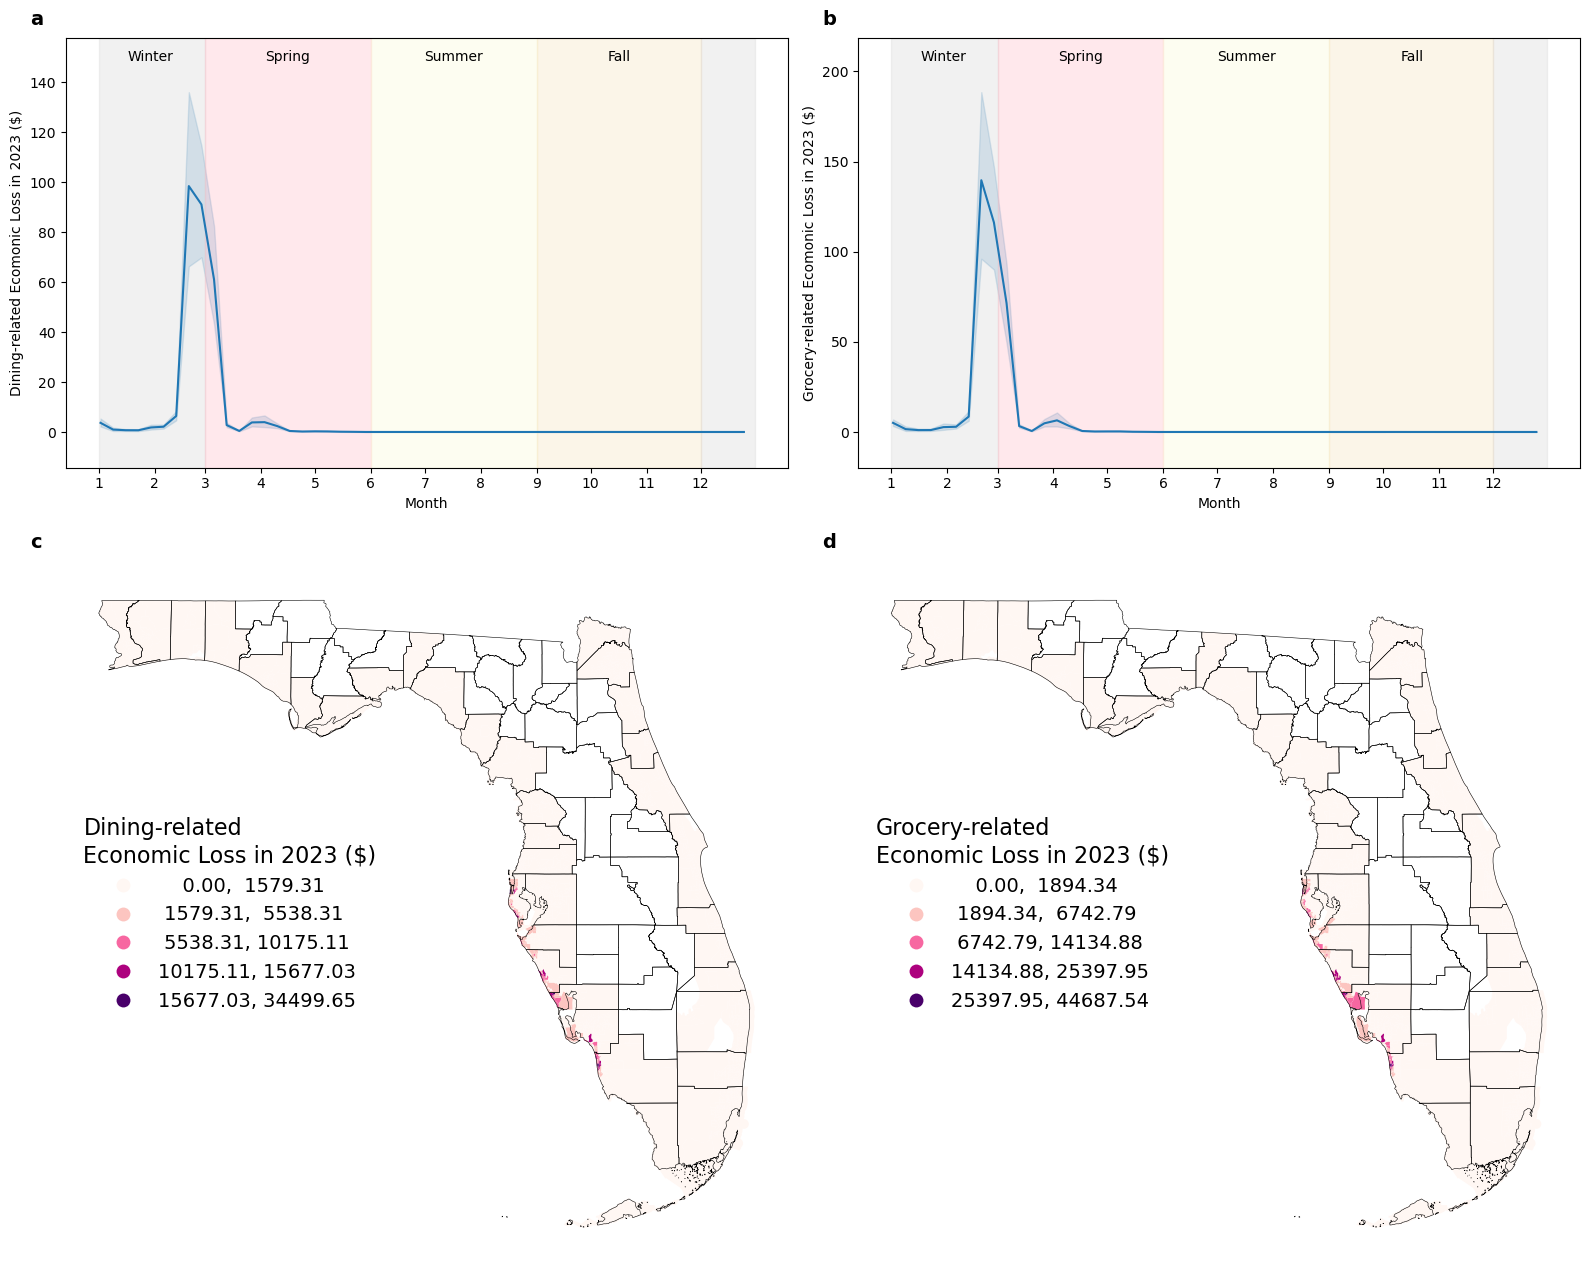

In [15]:
fig = plt.figure(figsize=(16, 13))
gs = gridspec.GridSpec(13, 16)

# Trend by weeks (line plot)
ax = fig.add_subplot(gs[0:5, 0:8])
y, y_label = 'expense_Eating', 'Dining-related Ecomonic Loss in 2023 ($)'
plot_expense_trend(ax, y, y_label)
ax.text(-0.05, 1.03, 'a', fontsize=14, weight='bold', transform=ax.transAxes)

ax = fig.add_subplot(gs[0:5, 8:16])
y, y_label = 'expense_Grocery', 'Grocery-related Ecomonic Loss in 2023 ($)'
plot_expense_trend(ax, y, y_label)
ax.text(-0.05, 1.03, 'b', fontsize=14, weight='bold', transform=ax.transAxes)


# Trend maps
temp = df3.groupby('GEOID').agg({'expense_Eating': 'sum', 'expense_Grocery': 'sum'}).reset_index()
temp = tracts.merge(temp, on='GEOID')

ax = fig.add_subplot(gs[5:13, 0:8])
y, y_label, colors = 'expense_Eating', 'Dining-related\nEconomic Loss in 2023 ($)', 'RdPu'
temp.plot(column=y, cmap=colors, scheme='NaturalBreaks', k=5, legend=True, ax=ax,
          legend_kwds={'title': y_label, 'loc': 'center left', 'frameon': False, 'title_fontsize': 16, 'fontsize': 14})
county.plot(facecolor='none', edgecolor='black', linewidth=0.4, ax=ax)
ax.axis('off')
# ax.set_title(y_label, fontsize=20)
ax.text(-0.05, 1.03, 'c', fontsize=14, weight='bold', transform=ax.transAxes)

ax = fig.add_subplot(gs[5:13, 8:16])
y, y_label, colors = 'expense_Grocery', 'Grocery-related\nEconomic Loss in 2023 ($)', 'RdPu'
temp.plot(column=y, cmap=colors, scheme='NaturalBreaks', k=5, legend=True, ax=ax,
          legend_kwds={'title': y_label, 'loc': 'center left', 'frameon': False, 'title_fontsize': 16, 'fontsize': 14})
county.plot(facecolor='none', edgecolor='black', linewidth=0.4, ax=ax)
ax.axis('off')
# ax.set_title(y_label, fontsize=20)
ax.text(-0.05, 1.03, 'd', fontsize=14, weight='bold', transform=ax.transAxes)

plt.tight_layout()
plt.show()